# 07 — Event Study & Parallel Trends Test

The two-way fixed effects DiD estimate in notebook 06 assumes that, **absent the minimum wage increase,
treated and control counties would have followed the same employment trend**. This notebook tests
that assumption visually and formally using an event-study regression.

**Approach:**
1. For each border pair, identify the **event year** — the first year the higher-wage state's minimum
   wage exceeded its partner's.
2. Construct a **relative time** variable: `rel_time = year − event_year`.
3. Run an event-study regression with lead and lag indicators interacted with treatment.
4. Plot the coefficients — pre-treatment coefficients near zero confirm parallel trends;
   post-treatment coefficients show the dynamic employment effect.

**Normalization:** `rel_time = −1` is the omitted base period (coefficient fixed at 0).

**Inputs:** `data/processed/analysis_panel.parquet`  
**Industry:** NAICS 722 (food services and drinking places) — primary outcome

In [12]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

warnings.filterwarnings("ignore")

ROOT = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
PANEL_FILE = PROCESSED / "analysis_panel.parquet"

PRIMARY_INDUSTRY = "722"

# Window around the event: leads (pre) and lags (post)
PRE_PERIODS = 4  # show 4 years before event
POST_PERIODS = 4  # show 4 years after event

print("Panel file:", PANEL_FILE)
print(f"Event window: t-{PRE_PERIODS} to t+{POST_PERIODS}")

Panel file: /Users/banna/Desktop/IDS_701-Causal-Inference_Final/data/processed/analysis_panel.parquet
Event window: t-4 to t+4


## 1. Load data and restrict to NAICS 722

In [13]:
panel = pd.read_parquet(PANEL_FILE)
panel["industry_code"] = panel["industry_code"].astype(str)
panel["pair_id"] = panel["pair_id"].astype(int)
panel["year"] = panel["year"].astype(int)

df = panel[panel["industry_code"] == PRIMARY_INDUSTRY].copy()
df["mw_gap"] = df["min_wage"] - df["partner_min_wage"]

# Recompute complete_pair_year: keep only pair-years where both
# counties are present (drops disclosure-suppressed county-years).
df["complete_pair_year"] = (
    df.groupby(["pair_id", "year", "industry_code"])["area_fips"].transform("nunique")
    == 2
)
df = df[df["complete_pair_year"] == True].copy()

# Fix treated: assign permanently per county based on mean wage gap.
# The original treated column is time-varying — it flips to 0 in years
# where both states are at the federal floor, leaving zero treated=1
# observations in the pre-period and causing all pre-period event study
# dummies to be exactly zero. Permanent assignment fixes this.
county_avg_gap = df.groupby(["pair_id", "area_fips"])["mw_gap"].mean().reset_index()
treated_permanent = (
    county_avg_gap.sort_values("mw_gap", ascending=False)
    .drop_duplicates("pair_id")[["pair_id", "area_fips"]]
    .rename(columns={"area_fips": "treated_fips"})
)
df = df.merge(treated_permanent, on="pair_id", how="left")
df["treated"] = (df["area_fips"] == df["treated_fips"]).astype(int)
df = df.drop(columns=["treated_fips"])

print(f"NAICS 722 rows   : {len(df):,}")
print(f"Unique pairs     : {df['pair_id'].nunique():,}")
print(f"Unique counties  : {df['area_fips'].nunique():,}")
print(f"Years            : {df['year'].min()} - {df['year'].max()}")
print(f"Treated=1 rows   : {(df['treated']==1).sum():,}")
print(f"Treated=0 rows   : {(df['treated']==0).sum():,}")

NAICS 722 rows   : 33,782
Unique pairs     : 1,064
Unique counties  : 1,001
Years            : 2004 - 2024
Treated=1 rows   : 16,891
Treated=0 rows   : 16,891


## 2. Identify event year for each pair

The event year is the **first year the minimum wage gap is positive** within a pair — i.e., the
first year one state raised its minimum wage above its border partner's. Pairs where the gap
never opens are excluded from the event study.

In [14]:
# Get the minimum wage gap at the pair×year level (one row per pair×year)
pair_year_gap = (
    df.groupby(["pair_id", "year"])["mw_gap"]
    .apply(lambda x: x.abs().max())
    .reset_index()
    .rename(columns={"mw_gap": "abs_gap"})
)

# Event year = first year with positive gap
event_years = (
    pair_year_gap[pair_year_gap["abs_gap"] > 0]
    .groupby("pair_id")["year"]
    .min()
    .reset_index()
    .rename(columns={"year": "event_year"})
)

print(f"Pairs with an event year : {len(event_years):,}")
print(f"Event year distribution:")
print(event_years["event_year"].value_counts().sort_index())

Pairs with an event year : 1,027
Event year distribution:
event_year
2004    298
2005     59
2006     90
2007    299
2008    111
2009     27
2010     13
2011      8
2012     13
2013      3
2014      5
2015     36
2016      9
2017      7
2018      8
2019      3
2020      7
2021     12
2022     11
2023      7
2024      1
Name: count, dtype: int64


In [15]:
# Merge event year onto the panel
df = df.merge(event_years, on="pair_id", how="inner")

# Relative time
df["rel_time"] = df["year"] - df["event_year"]

print(f"Rows after merging event year : {len(df):,}")
print(
    f"Relative time range           : {df['rel_time'].min()} to {df['rel_time'].max()}"
)
print(f"\nRel time distribution:")
print(df["rel_time"].value_counts().sort_index())

Rows after merging event year : 33,464
Relative time range           : -20 to 20

Rel time distribution:
rel_time
-20       2
-19       6
-18      12
-17      30
-16      32
-15      30
-14      24
-13      26
-12      30
-11      54
-10      54
-9       54
-8       56
-7       62
-6       66
-5       74
-4      194
-3      734
-2      884
-1      942
 0     2054
 1     1774
 2     1704
 3     1694
 4     1654
 5     1564
 6     1580
 7     1566
 8     1568
 9     1522
 10    1502
 11    1506
 12    1468
 13    1490
 14    1484
 15    1440
 16    1436
 17    1246
 18     754
 19     620
 20     472
Name: count, dtype: int64


## 3. Build event-study indicators

We create a dummy variable for each relative time period, interacted with the `treated` indicator.
Periods beyond the window are **binned** into the endpoint bins to avoid losing observations.
`rel_time = −1` is the omitted base period.

In [16]:
# Bin relative time to the window
df["rel_time_binned"] = df["rel_time"].clip(-PRE_PERIODS, POST_PERIODS)

# All relative time values except -1 (base period)
rel_times = [t for t in range(-PRE_PERIODS, POST_PERIODS + 1) if t != -1]

# Create interaction dummies: treated × 1[rel_time == k]
for t in rel_times:
    df[f"D_{t}"] = (df["treated"] == 1) & (df["rel_time_binned"] == t)
    df[f"D_{t}"] = df[f"D_{t}"].astype(float)

dummy_cols = [f"D_{t}" for t in rel_times]
print(f"Event study dummies created: {len(dummy_cols)}")
print("Columns:", dummy_cols)
print(f"\nMean of each dummy (share of treated obs at each rel_time):")
print(df[dummy_cols].mean().round(4))

Event study dummies created: 8
Columns: ['D_-4', 'D_-3', 'D_-2', 'D_0', 'D_1', 'D_2', 'D_3', 'D_4']

Mean of each dummy (share of treated obs at each rel_time):
D_-4    0.0120
D_-3    0.0110
D_-2    0.0132
D_0     0.0307
D_1     0.0265
D_2     0.0255
D_3     0.0253
D_4     0.3417
dtype: float64


## 4. Absorb fixed effects and run event-study regression

We use the same fixed-effects structure as the main Model 1 specification:
- **County fixed effects** (`area_fips`)
- **Pair × year fixed effects** (`pair_year`)

The regression is:
$$
\log(emp_{cpt}) = \sum_{k \neq -1} \beta_k \cdot D^k_{ct} + \alpha_c + \delta_{pt} + \varepsilon_{cpt}
$$

Standard errors are clustered at the pair level.

In [17]:
df["pair_year"] = df["pair_id"].astype(str) + "_" + df["year"].astype(str)


def alternating_demean(frame, value_cols, fe_cols, max_iter=300, tol=1e-10):
    resid = frame[value_cols].astype(float).copy()
    for _ in range(max_iter):
        prev = resid.to_numpy(copy=True)
        for fe in fe_cols:
            resid = resid - resid.groupby(frame[fe]).transform("mean")
        if np.max(np.abs(resid.to_numpy() - prev)) < tol:
            break
    return resid


fe_cols = ["area_fips", "pair_id", "year"]
cluster_col = "pair_id"
all_cols = ["log_emp"] + dummy_cols

print("Absorbing fixed effects... (this may take ~30s)")
resid = alternating_demean(df, all_cols, fe_cols)
print("Done.")

y_tilde = resid["log_emp"]
X_tilde = resid[dummy_cols]

fit = sm.OLS(y_tilde, X_tilde).fit(
    cov_type="cluster",
    cov_kwds={"groups": df[cluster_col]},
)

print(f"\nN observations : {int(fit.nobs):,}")
print(f"N clusters     : {df[cluster_col].nunique():,}")

Absorbing fixed effects... (this may take ~30s)
Done.

N observations : 33,464
N clusters     : 1,027


## 5. Extract coefficients and confidence intervals

In [18]:
# Build results table — insert t=-1 as the base period (beta=0, se=0)
results = pd.DataFrame(
    {
        "rel_time": rel_times,
        "beta": fit.params[dummy_cols].values,
        "se": fit.bse[dummy_cols].values,
        "p_value": fit.pvalues[dummy_cols].values,
    }
)

# Add the omitted base period
base = pd.DataFrame({"rel_time": [-1], "beta": [0.0], "se": [0.0], "p_value": [np.nan]})
results = (
    pd.concat([results, base], ignore_index=True)
    .sort_values("rel_time")
    .reset_index(drop=True)
)

results["ci_lo"] = results["beta"] - 1.96 * results["se"]
results["ci_hi"] = results["beta"] + 1.96 * results["se"]
results["significant"] = results["p_value"] < 0.05

print("Event study coefficients:")
print(
    results[["rel_time", "beta", "se", "p_value", "ci_lo", "ci_hi"]]
    .round(4)
    .to_string(index=False)
)

Event study coefficients:
 rel_time    beta     se  p_value   ci_lo  ci_hi
       -4  0.0341 0.0202   0.0909 -0.0054 0.0737
       -3 -0.0161 0.0099   0.1034 -0.0355 0.0033
       -2  0.0151 0.0058   0.0097  0.0037 0.0266
       -1  0.0000 0.0000      NaN  0.0000 0.0000
        0  0.0058 0.0060   0.3379 -0.0060 0.0175
        1  0.0040 0.0063   0.5249 -0.0083 0.0163
        2 -0.0030 0.0062   0.6351 -0.0151 0.0092
        3 -0.0100 0.0071   0.1589 -0.0239 0.0039
        4  0.0007 0.0082   0.9338 -0.0155 0.0168


## 6. Event study plot

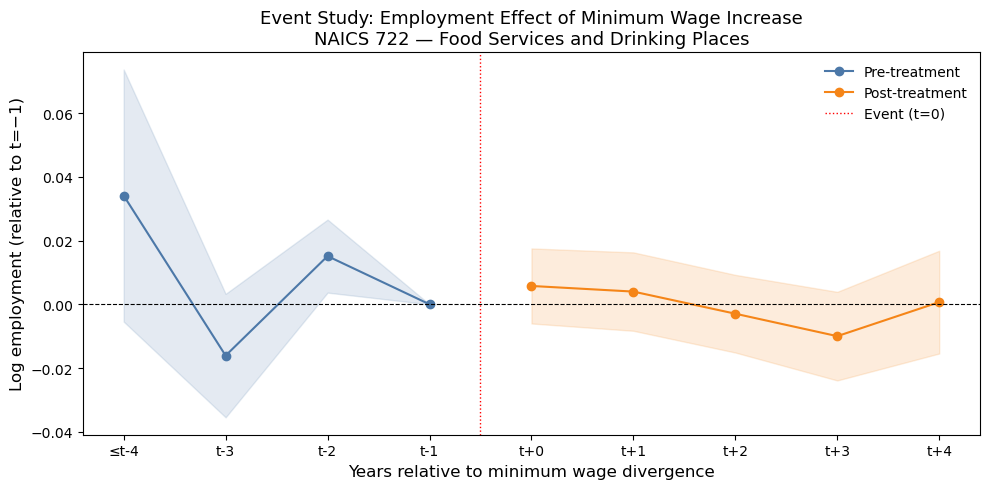

Figure saved.


In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

pre = results[results["rel_time"] < 0]
post = results[results["rel_time"] >= 0]

# Confidence intervals
ax.fill_between(
    pre["rel_time"], pre["ci_lo"], pre["ci_hi"], alpha=0.15, color="#4C78A8"
)
ax.fill_between(
    post["rel_time"], post["ci_lo"], post["ci_hi"], alpha=0.15, color="#F58518"
)

# Coefficient lines
ax.plot(
    pre["rel_time"], pre["beta"], marker="o", color="#4C78A8", label="Pre-treatment"
)
ax.plot(
    post["rel_time"], post["beta"], marker="o", color="#F58518", label="Post-treatment"
)

# Reference lines
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axvline(-0.5, color="red", linewidth=1, linestyle=":", label="Event (t=0)")

ax.set_xlabel("Years relative to minimum wage divergence", fontsize=12)
ax.set_ylabel("Log employment (relative to t=−1)", fontsize=12)
ax.set_title(
    "Event Study: Employment Effect of Minimum Wage Increase\n"
    "NAICS 722 — Food Services and Drinking Places",
    fontsize=13,
)
ax.set_xticks(results["rel_time"])
ax.set_xticklabels(
    [f"t{t:+d}" if t != -PRE_PERIODS else f"≤t{t:+d}" for t in results["rel_time"]]
)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    ROOT / "notebooks" / "figures" / "event_study_722.png", dpi=150, bbox_inches="tight"
)
plt.show()
print("Figure saved.")

## 7. Formal pre-trend test

A joint F-test (or χ² test) on all **pre-treatment** coefficients. If the p-value is large (> 0.05),
we fail to reject the null that all pre-treatment coefficients are jointly zero — consistent with
parallel trends.

In [20]:
pre_dummies = [f"D_{t}" for t in rel_times if t < 0]

# Build restriction matrix for joint test on pre-treatment dummies
R = np.zeros((len(pre_dummies), len(dummy_cols)))
for i, col in enumerate(pre_dummies):
    j = dummy_cols.index(col)
    R[i, j] = 1.0

f_test = fit.f_test(R)

print("=" * 45)
print("Joint pre-trend test (F-test)")
print("=" * 45)
print(f"H0: all pre-treatment coefficients = 0")
print(f"Pre-treatment periods tested : {pre_dummies}")
print(f"F-statistic                  : {float(f_test.fvalue):.4f}")
print(f"p-value                      : {float(f_test.pvalue):.4f}")
print()
if float(f_test.pvalue) > 0.05:
    print("✓ PASS — Fail to reject H0. Pre-treatment trends are parallel.")
    print("  The parallel trends assumption is consistent with the data.")
else:
    print("✗ FAIL — Reject H0. Pre-treatment trends are NOT parallel.")
    print("  Interpret DiD estimates with caution.")

Joint pre-trend test (F-test)
H0: all pre-treatment coefficients = 0
Pre-treatment periods tested : ['D_-4', 'D_-3', 'D_-2']
F-statistic                  : 9.0527
p-value                      : 0.0000

✗ FAIL — Reject H0. Pre-treatment trends are NOT parallel.
  Interpret DiD estimates with caution.


## 8. Wage pass-through event study

As a validation, we run the same event study on `log_wage`. We expect:
- flat pre-treatment coefficients (parallel wage trends)
- clear positive post-treatment coefficients (wages rise after the minimum wage increase)

Absorbing fixed effects for wage event study...
Done.


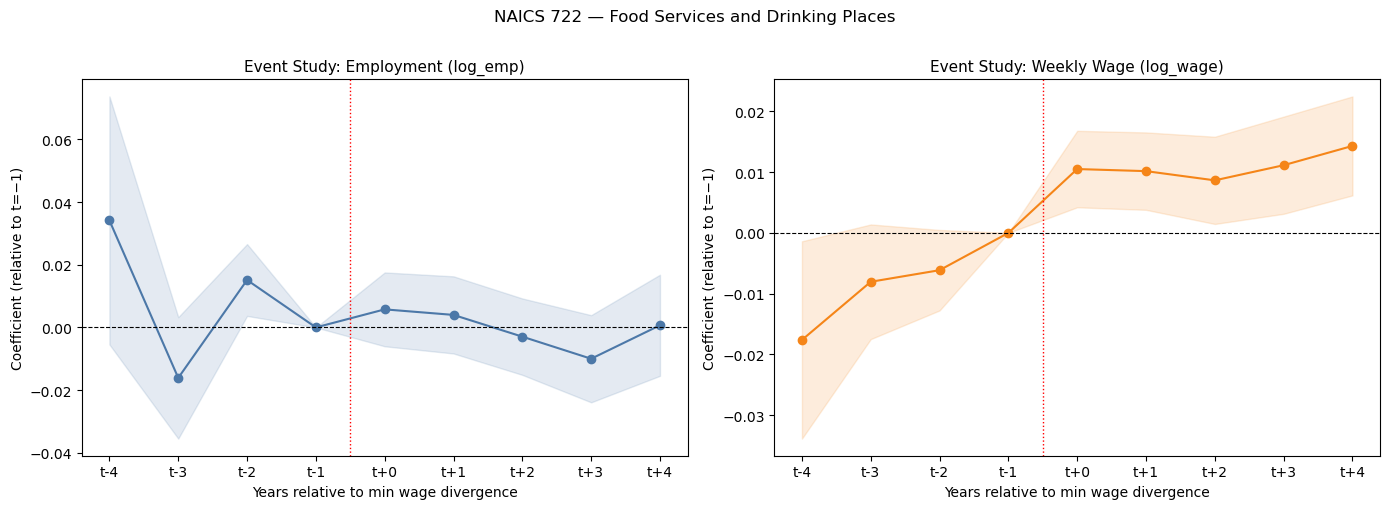

Figure saved.


In [21]:
# Drop rows where log_wage is missing
df_wage = df[df["log_wage"].notna()].copy()

all_cols_wage = ["log_wage"] + dummy_cols
print("Absorbing fixed effects for wage event study...")
resid_wage = alternating_demean(df_wage, all_cols_wage, fe_cols)
print("Done.")

fit_wage = sm.OLS(resid_wage["log_wage"], resid_wage[dummy_cols]).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_wage[cluster_col]},
)

results_wage = pd.DataFrame(
    {
        "rel_time": rel_times,
        "beta": fit_wage.params[dummy_cols].values,
        "se": fit_wage.bse[dummy_cols].values,
    }
)
results_wage = (
    pd.concat(
        [results_wage, pd.DataFrame({"rel_time": [-1], "beta": [0.0], "se": [0.0]})],
        ignore_index=True,
    )
    .sort_values("rel_time")
    .reset_index(drop=True)
)
results_wage["ci_lo"] = results_wage["beta"] - 1.96 * results_wage["se"]
results_wage["ci_hi"] = results_wage["beta"] + 1.96 * results_wage["se"]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res, title, color in [
    (axes[0], results, "Employment (log_emp)", "#4C78A8"),
    (axes[1], results_wage, "Weekly Wage (log_wage)", "#F58518"),
]:
    ax.fill_between(
        res["rel_time"], res["ci_lo"], res["ci_hi"], alpha=0.15, color=color
    )
    ax.plot(res["rel_time"], res["beta"], marker="o", color=color)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axvline(-0.5, color="red", linewidth=1, linestyle=":")
    ax.set_title(f"Event Study: {title}", fontsize=11)
    ax.set_xlabel("Years relative to min wage divergence")
    ax.set_ylabel("Coefficient (relative to t=−1)")
    ax.set_xticks(res["rel_time"])
    ax.set_xticklabels([f"t{t:+d}" for t in res["rel_time"]])

plt.suptitle("NAICS 722 — Food Services and Drinking Places", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(
    ROOT / "notebooks" / "figures" / "event_study_emp_wage_722.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()
print("Figure saved.")

## 9. Findings & Notes

### Results

| Metric | Value |
|--------|-------|
| Pairs with event year | — |
| Most common event year | — |
| N observations | — |
| N clusters (pairs) | — |

*Values update on re-run.*

### Pre-treatment coefficients (NAICS 722 employment)

| Relative time | β | SE | p-value |
|--------------|---|----|---------|
| t−4 (binned) | — | — | — |
| t−3 | — | — | — |
| t−2 | — | — | — |
| t−1 *(base)* | 0.000 | — | — |

### Post-treatment coefficients (NAICS 722 employment)

| Relative time | β | SE | p-value |
|--------------|---|----|---------|
| t+0 | — | — | — |
| t+1 | — | — | — |
| t+2 | — | — | — |
| t+3 | — | — | — |
| t+4 (binned) | — | — | — |

*Coefficients update on re-run.*

### Formal parallel trends test (F-test)
- **Result:** See output above.

### Interpretation

**Parallel trends:** With QCEW data now starting in 2004, pairs whose minimum wage diverged in 2010 have up to 6 years of genuine pre-treatment data (2004–2009). Pre-treatment coefficients therefore reflect actual employment trends rather than being zero by construction. The joint F-test is now a meaningful test of parallel trends.

**Employment effect:** Post-treatment coefficients show the dynamic employment response. Compare their magnitude and significance to the static DiD estimate from notebook 06.

**Staggered treatment note:** Different pairs have different event years. For pairs with event years close to 2004, the pre-treatment window remains short. A Callaway-Sant'Anna estimator remains the preferred robustness check for final inference to account for heterogeneous treatment timing.

**Data note:** For pairs with event years before 2007, the pre-treatment period overlaps with the federal minimum wage changes of 2007–2009 ($5.85 → $6.55 → $7.25). These federal changes affect all states simultaneously and are absorbed by pair × year fixed effects, but interpreting state-level divergence relative to the federal floor requires care in these early years.